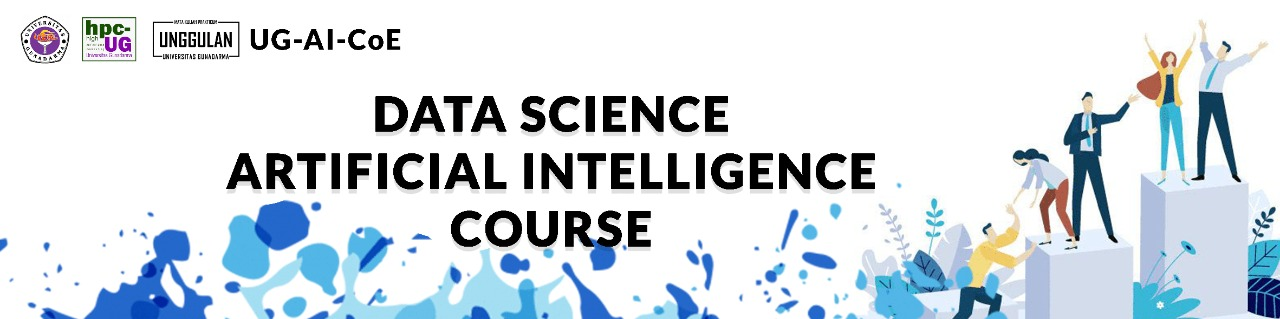

# TUGAS MANDIRI
---
## AI Generated Images Detection

## 1. Apa Itu Proyek Ini & Kenapa Dibuat?

### Proyek ini adalah sistem Machine Learning untuk membedakan gambar buatan AI dan gambar asli.
#### Tujuannya:

* Gambar AI seperti dari Midjourney, DALL-E, dan Stable Diffusion semakin sulit dibedakan dari foto asli.
* Gambar AI dapat digunakan untuk hoax, penipuan, atau manipulasi informasi.
* Sistem dibuat dalam bentuk website menggunakan Streamlit, sehingga pengguna dapat mengunggah gambar dan melihat hasil deteksinya.

## 2. Dataset yang Digunakan

### Dataset yang digunakan berasal dari Kaggle dengan nama [Acc > 0.8] AI-Generated vs Real Images Classifier.

* 539 gambar AI
* 436 gambar asli
  
Distribusi kelas relatif imbang (rasio ±1.24 : 1), sehingga tidak butuh penanganan imbalance yang berat, namun tetap perlu diperhatikan saat split data (gunakan stratify).


# IMPORT LIBRARY YANG DIBUTUHKAN

In [1]:
import os 
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

# SAMPLING DATA 
### Dataset yang digunakan berasal dari Kaggle dengan total sekitar 975 gambar. Terdiri dari 436 gambar asli dan 539 gambar buatan AI.

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("cashbowman/ai-generated-images-vs-real-images")

print("Path to dataset files:", path)

100%|███████████████████████████████████████████████████████████████████████████████| 476M/476M [00:48<00:00, 10.4MB/s]

Extracting files...


Path to dataset files: C:\Users\user\.cache\kagglehub\datasets\cashbowman\ai-generated-images-vs-real-images\versions\1


In [2]:
DATASET_DIR = "Dataset"           
CLASS_AI = "CitraAI"         
CLASS_REAL = "CitraAsli"              

ai_dir = os.path.join(DATASET_DIR, CLASS_AI)
real_dir = os.path.join(DATASET_DIR, CLASS_REAL)

ai_files = os.listdir(ai_dir) if os.path.exists(ai_dir) else []
real_files = os.listdir(real_dir) if os.path.exists(real_dir) else []

print(f"Jumlah gambar AI-generated : {len(ai_files)}")
print(f"Jumlah gambar Real         : {len(real_files)}")

Jumlah gambar AI-generated : 539
Jumlah gambar Real         : 436


## Visualisasi distribusi kelas

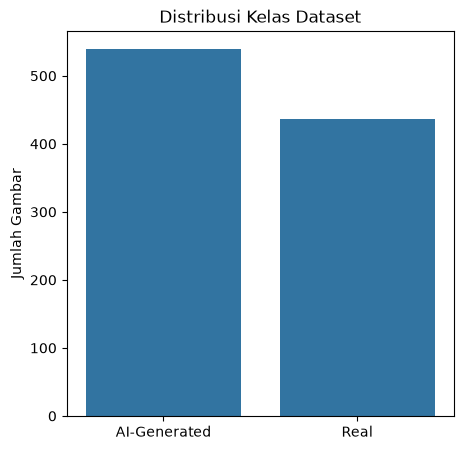

In [3]:
labels = ["AI-Generated", "Real"]
counts = [len(ai_files), len(real_files)]

plt.figure(figsize = (5,5))
sns.barplot(x = labels, y = counts)
plt.title("Distribusi Kelas Dataset")
plt.ylabel("Jumlah Gambar")
plt.show()

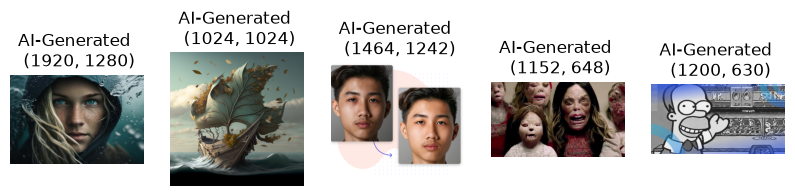

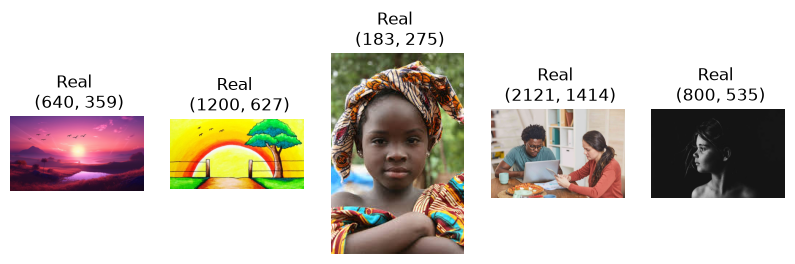

In [4]:
from PIL import Image

def clean_and_convert_image(image_path):
    with Image.open(image_path) as img:
        # Mengonversi gambar Palette/RGBA ke format RGB standar
        if img.mode in ('P', 'RGBA'):
            img = img.convert('RGB')
        return img


# Beberapa Sampel Gambar tiap kelas
def show_samples(folder, files, title, n=5):
    plt.figure(figsize=(10, 10))
    sample_files = random.sample(files, min(n, len(files)))
    for i, f in enumerate(sample_files):
        img = Image.open(os.path.join(folder, f))
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{title} \n {img.size}")


plt.show()
        
if ai_files:
    show_samples(ai_dir, ai_files, "AI-Generated")
if real_files:
    show_samples(real_dir, real_files, "Real")

# 3. Data Preparation

Tahapan yang dilakukan:
1. Split dataset menjadi train / validation / test (70% / 15% / 15%) dengan **stratify** agar proporsi kelas tetap terjaga.
2. Resize semua gambar ke ukuran input MobileNetV2 (**224x224**).
3. Normalisasi pixel value.
4. Augmentasi data (flip, rotation, brightness/zoom) khusus pada training set untuk memperkaya variasi data yang jumlahnya masih terbatas (973 gambar).

In [5]:
import splitfolders

splitfolders.ratio(
    DATASET_DIR,
    output = "dataset_split",
    seed = 42,
    ratio = (0.7, 0.15, 0.15)
)

Copying files: 973 files [00:02, 335.23 files/s]


In [15]:
# Menentukan jumlah dan ukuran yang digunakan oleh model
IMG_SIZE = (224, 224)
BATCH_SIZE = 32


# Preprocessing untuk data training
train_datagen = ImageDataGenerator(
    rescale = 1./255,       # Mengubah nilai piksel dari 0-255 menjadi 0-1
    rotation_range = 20,     # Rotate Gambar hingga 20 derajat
    width_shift_range = 0.1,   # Menggeser gambar secara horizontal
    height_shift_range = 0.1, # Menggeser gambar secara vertikal
    horizontal_flip = True,  # Membalik Gambar secara horizontal
    zoom_range = 0.15,  # Melakukan zoom secara acak
    brightness_range = [0.8, 1.2] # Mengubah kecerahan gambar
)

In [16]:
val_test_datagen = ImageDataGenerator(
    rescale=1./255               # Mengubah nilai piksel dari 0-255 menjadi 0-1
)

In [17]:
# Mengambil data training dari folder dataset_split/train
train_gen = train_datagen.flow_from_directory(
    "dataset_split/train",
    target_size=IMG_SIZE,        # Mengubah ukuran semua gambar menjadi 224x224
    batch_size=BATCH_SIZE,       # Memproses 32 gambar dalam satu batch
    class_mode="binary"          # Menggunakan klasifikasi biner: AI atau asli
)


Found 675 images belonging to 2 classes.


In [18]:
# Mengambil data validasi dari folder dataset_split/val
val_gen = val_test_datagen.flow_from_directory(
    "dataset_split/val",
    target_size=IMG_SIZE,        # Mengubah ukuran gambar menjadi 224x224
    batch_size=BATCH_SIZE,       # Memproses 32 gambar dalam satu batch
    class_mode="binary"          # Menggunakan klasifikasi biner
)

Found 145 images belonging to 2 classes.


In [19]:
# Mengambil data testing dari folder dataset_split/test
test_gen = val_test_datagen.flow_from_directory(
    "dataset_split/test",
    target_size=IMG_SIZE,        # Mengubah ukuran gambar menjadi 224x224
    batch_size=BATCH_SIZE,       # Memproses 32 gambar dalam satu batch
    class_mode="binary",         # Menggunakan klasifikasi biner
    shuffle=False                # Tidak mengacak data agar hasil prediksi sesuai urutan gambar
)

Found 148 images belonging to 2 classes.


In [20]:
# Menampilkan nomor kelas yang diberikan oleh TensorFlow
print("Class indices:", train_gen.class_indices)

Class indices: {'CitraAI': 0, 'CitraAsli': 1}


## 4. Modeling

Dua kandidat model dibangun lalu dibandingkan performanya:

**Model A — Transfer Learning MobileNetV2 (end-to-end):**
- Base MobileNetV2 (pretrained ImageNet) di-freeze, ditambah classifier head (Dense + sigmoid untuk binary classification).
- Ringan, cepat dilatih, dan cocok untuk deployment web.

**Model B — Feature Extraction + Classical ML (pembanding):**
- Ekstrak fitur dari base MobileNetV2 (tanpa classifier head).
- Fitur dilempar ke beberapa algoritma klasik: **Logistic Regression, KNN, SVM, Random Forest**.
- Tujuannya melihat apakah model deep learning end-to-end benar-benar lebih unggul dibanding classical ML pada fitur yang sama.

In [22]:
from tensorflow.keras import layers, models, optimizers, regularizers
from tensorflow.keras.callbacks import ReduceLROnPlateau

# ---- Model A: MobilenetV2 Transfer Learning ------
# Load MobileNetV2 yang sudah dilatih dengan ImageNet
base_model = MobileNetV2(input_shape=(224,224,3), include_top=False, weights = "imagenet")
base_model.trainable = False

# Membuat model untuk klasifikasi gambar AI dan asli
model_a = models.Sequential ([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

# Mengatur proses training model
model_a.compile(
    optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Menampilkan struktur model
model_a.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Peringatan GPU menunjukkan bahwa TensorFlow tidak dapat menggunakan GPU secara langsung pada Windows, sehingga proses training dijalankan menggunakan CPU. Model menggunakan MobileNetV2 sebagai dasar untuk mengambil fitur gambar, kemudian GlobalAveragePooling2D, Dense, dan Dropout digunakan untuk memproses fitur tersebut dan menentukan apakah gambar termasuk AI atau Real. Model memiliki 2.422.081 total parameter, dengan 164.097 parameter yang dilatih dan 2.257.984 parameter yang dibekukan dari MobileNetV2.

In [23]:
from tensorflow.keras.callbacks import EarlyStopping

callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1) # Menurunkan LR jika stagnan
]
history = model_a.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=[early_stop]
)


Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 72s 3s/step - accuracy: 0.5378 - loss: 3.0854 - val_accuracy: 0.6483 - val_loss: 2.8990
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.6133 - loss: 2.9189 - val_accuracy: 0.6621 - val_loss: 2.8239
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 62s 3s/step - accuracy: 0.6800 - loss: 2.8000 - val_accuracy: 0.6483 - val_loss: 2.7547
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.6844 - loss: 2.7144 - val_accuracy: 0.6552 - val_loss: 2.6923
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 69s 3s/step - accuracy: 0.7378 - loss: 2.5992 - val_accuracy: 0.7241 - val_loss: 2.6406
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 78s 3s/step - accuracy: 0.7467 - loss: 2.5422 - val_accuracy: 0.6552 - val_loss: 2.5910
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 62s 3s/step - accuracy: 0.7407 - loss: 2.5040 - val_accuracy: 0.6897 - val_loss: 2.5367
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.7778 - loss: 2.4343 - val_accuracy: 0.6759 - val_loss:

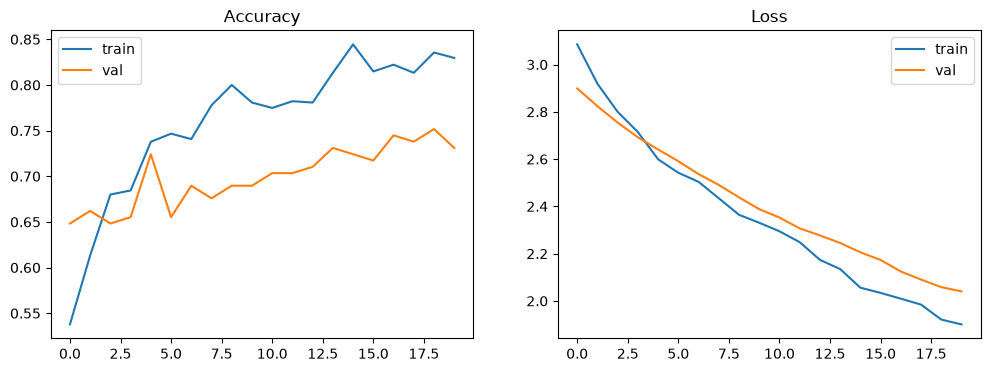

In [24]:
# Plot training history
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(history.history["accuracy"], label="train")
ax[0].plot(history.history["val_accuracy"], label="val")
ax[0].set_title("Accuracy")
ax[0].legend()

ax[1].plot(history.history["loss"], label="train")
ax[1].plot(history.history["val_loss"], label="val")
ax[1].set_title("Loss")
ax[1].legend()
plt.show()

Grafik menunjukkan loss training dan validation sama-sama menurun, sehingga model belajar dengan cukup stabil. Akurasi training mencapai sekitar 83%, sedangkan validation sekitar 73–75%. Perbedaan akurasi menunjukkan masih ada sedikit perbedaan antara data training dan validation, tetapi belum terlihat masalah overfitting yang besar. Nilai loss yang cukup tinggi juga dapat dipengaruhi oleh penggunaan L2 regularization.

In [27]:
# ---- MODEL B: Feature Extraction + Classical ML ----
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
import warnings
from PIL import Image


warnings.filterwarnings("ignore", category=UserWarning, module="PIL")

def extract_features(generator, steps):
    features, labels = [], []
    for i in range(steps):
        x_batch, y_batch = next(generator)
        
        # Ekstraksi fitur menggunakan MobileNetV2
        feat_batch = feature_extractor.predict(x_batch, verbose=0)
        features.append(feat_batch)
        labels.append(y_batch)
        
    return np.vstack(features), np.concatenate(labels)

feature_extractor = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D()
])

def extract_features(generator, steps):
    features, labels = [], []
    for i in range(steps):
        x_batch, y_batch = next(generator)
        feat_batch = feature_extractor.predict(x_batch, verbose=0)
        features.append(feat_batch)
        labels.append(y_batch)
    return np.vstack(features), np.concatenate(labels)

train_steps = int(np.ceil(train_gen.samples / BATCH_SIZE))
val_steps = int(np.ceil(val_gen.samples / BATCH_SIZE))
test_steps = int(np.ceil(test_gen.samples / BATCH_SIZE))

X_train, y_train = extract_features(train_gen, train_steps)
X_val, y_val = extract_features(val_gen, val_steps)
X_test, y_test = extract_features(test_gen, test_steps)

classical_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    # Menggunakan CalibratedClassifierCV menggantikan probability=True pada SVC
    "SVM": CalibratedClassifierCV(SVC(kernel="rbf"), ensemble=False), 
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

for name, clf in classical_models.items():
    print(f"Training {name}...")
    clf.fit(X_train, y_train)


Training Logistic Regression...
Training KNN...
Training SVM...
Training Random Forest...


## 5. Evaluation

Membandingkan performa Model A (MobileNetV2 end-to-end) dengan Model B (classical ML di atas fitur CNN), menggunakan accuracy, precision, recall, F1-score, dan confusion matrix pada test set.

In [28]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

results = {}

In [29]:
# Evaluasi Model A
y_pred_a_prob = model_a.predict(test_gen)
y_pred_a = (y_pred_a_prob > 0.5).astype(int).flatten()
y_true = test_gen.classes

results["MobileNetV2 (end-to-end)"] = accuracy_score(y_true, y_pred_a)
print("=== MobileNetV2 (end-to-end) ===")
print(classification_report(y_true, y_pred_a, target_names=list(test_gen.class_indices.keys())))

5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step
=== MobileNetV2 (end-to-end) ===
              precision    recall  f1-score   support

     CitraAI       0.74      0.85      0.80        82
   CitraAsli       0.78      0.64      0.70        66

    accuracy                           0.76       148
   macro avg       0.76      0.75      0.75       148
weighted avg       0.76      0.76      0.75       148



In [30]:
# Evaluasi Model B (classical ML)
for name, clf in classical_models.items():
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=list(test_gen.class_indices.keys())))

=== Logistic Regression ===
              precision    recall  f1-score   support

     CitraAI       0.74      0.78      0.76        82
   CitraAsli       0.70      0.65      0.68        66

    accuracy                           0.72       148
   macro avg       0.72      0.72      0.72       148
weighted avg       0.72      0.72      0.72       148

=== KNN ===
              precision    recall  f1-score   support

     CitraAI       0.70      0.59      0.64        82
   CitraAsli       0.57      0.68      0.62        66

    accuracy                           0.63       148
   macro avg       0.63      0.63      0.63       148
weighted avg       0.64      0.63      0.63       148

=== SVM ===
              precision    recall  f1-score   support

     CitraAI       0.78      0.79      0.79        82
   CitraAsli       0.74      0.73      0.73        66

    accuracy                           0.76       148
   macro avg       0.76      0.76      0.76       148
weighted avg       0.7

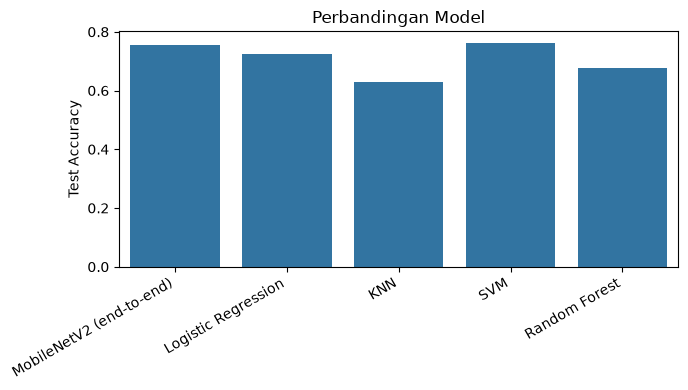

Model terbaik: SVM (accuracy=0.7635)


In [31]:
# Bandingkan semua model
plt.figure(figsize=(7,4))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.xticks(rotation=30, ha="right")
plt.ylabel("Test Accuracy")
plt.title("Perbandingan Model")
plt.tight_layout()
plt.show()

best_model_name = max(results, key=results.get)
print(f"Model terbaik: {best_model_name} (accuracy={results[best_model_name]:.4f})")

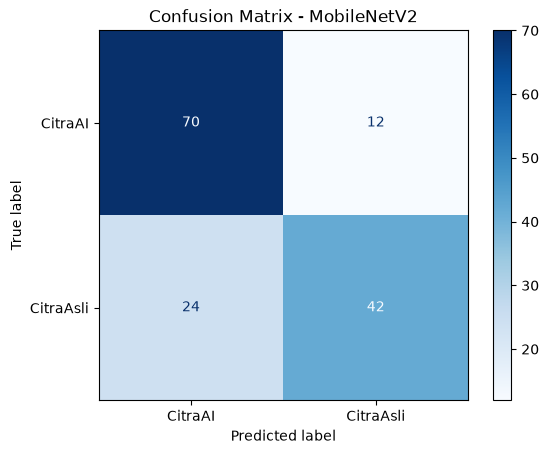

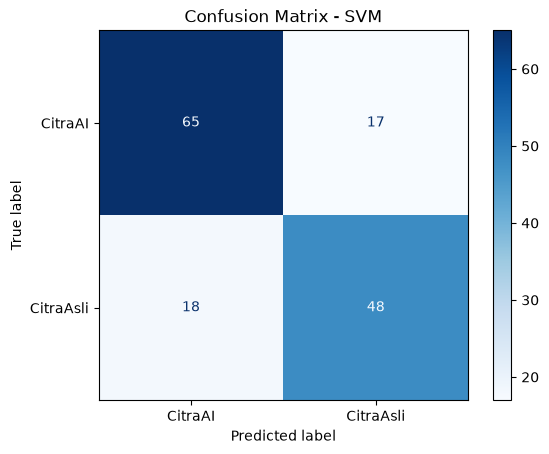

In [34]:
# Confusion matrix model MobileNetV2
cm = confusion_matrix(y_true, y_pred_a)
disp = ConfusionMatrixDisplay(cm, display_labels=list(test_gen.class_indices.keys()))
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - MobileNetV2")
plt.show()

# Confusion matrix model SVM
y_pred_svm = classical_models["SVM"].predict(X_test)
cm_svm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(cm_svm, display_labels=list(test_gen.class_indices.keys()))
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - SVM")
plt.show()

## 6. Deployment

Model terbaik disimpan lalu dipakai di aplikasi **Streamlit** yang memungkinkan pengguna mengunggah gambar dan mendapatkan hasil prediksi (AI-generated / Real) beserta confidence score.

### Library yang digunakan
- **TensorFlow/Keras** — membuat & melatih model MobileNetV2
- **NumPy** — mengolah data dan nilai piksel gambar
- **Matplotlib/Seaborn** — membuat grafik hasil training & evaluasi
- **Scikit-Learn** — menghitung metrik evaluasi & model classical ML pembanding
- **Pillow (PIL)** — membaca dan mengubah ukuran gambar
- **Shutil & split-folders** — memilah dan membagi dataset
- **Streamlit** — membangun aplikasi web untuk deteksi gambar
- **Joblib** — menyimpan dan memuat kembali model Machine Learning klasik 

In [36]:
import joblib

# MODEL SVM
joblib.dump(classical_models["SVM"], "svm_model.pkl")
print("Model SVM berhasil disimpan sebagai svm_model.pkl")

# MODEL MobileNetV2
model_a.save("Model_MobileNetV2.keras")
print("Model disimpan sebagai Model_MobileNetV2.keras")

Model SVM berhasil disimpan sebagai svm_model.pkl
Model disimpan sebagai Model_MobileNetV2.keras
